# OMI Real Estate Quotations — Data Quality & Exploratory Analysis

This notebook builds a reproducible analytical dataset from the semiannual **OMI (Osservatorio del Mercato Immobiliare)** quotations published by the *Agenzia delle Entrate*.

### Analytical objective

Move from raw OMI releases to a validated dataset that can support: temporal market analysis, geographic comparisons, quotation-range analysis, property-category analysis, and future joins with transaction volumes.

### Pipeline

**Raw CSV files → consolidation → data quality → cleaning → validation → feature engineering → EDA → insights**

**Source:** Agenzia delle Entrate — Osservatorio del Mercato Immobiliare.


## 1. Setup

The notebook keeps the analytical stack lightweight: `pandas` for data preparation, `numpy` for numerical transformations and `matplotlib` for visualization. The project root is resolved from the notebook location so the code does not depend on a specific working directory.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'quotations'
assert RAW_DIR.exists(), f'Raw quotations directory not found: {RAW_DIR}'

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 2. Load and consolidate the raw OMI releases

OMI quotations are supplied as one semicolon-separated CSV per semester. Each file is loaded independently so that unexpected files can be identified early and the reference period is retained explicitly.


In [3]:
files = sorted(RAW_DIR.glob('omi_quotations_*.csv'))

if not files:
    raise FileNotFoundError(f'No OMI quotation files found in {RAW_DIR}')

records = []
invalid_files = []

for path in files:
    parts = path.stem.rsplit('_', 2)

    # Expected format: omi_quotations_YYYY_S1 / omi_quotations_YYYY_S2
    if (
        len(parts) != 3
        or not parts[1].isdigit()
        or parts[2] not in {'S1', 'S2'}
    ):
        invalid_files.append(path.name)
        continue

    year = int(parts[1])
    semester = parts[2]

    df_part = pd.read_csv(
        path,
        sep=';',
        low_memory=False,
    )

    df_part['reference_year'] = year
    df_part['reference_semester'] = semester
    df_part['reference_period'] = f'{year}-{semester}'

    records.append(df_part)

if invalid_files:
    print(
        'Files skipped because their name does not match '
        'the expected convention:'
    )
    print(invalid_files)

if not records:
    raise ValueError(
        'No valid OMI quotation files were found.'
    )

omi = pd.concat(records, ignore_index=True)

print(f'Files loaded: {len(records):,}')
print(f'Rows consolidated: {len(omi):,}')
print(f'Columns: {omi.shape[1]:,}')

Files loaded: 44
Rows consolidated: 7,516,495
Columns: 25


## 3. Initial dataset inspection

Inspect the schema, temporal coverage and raw structure before changing any values.


In [4]:
display(omi.head())
display(omi.dtypes.to_frame('dtype'))
print('Raw shape:', omi.shape)
print('Duplicate rows:', omi.duplicated().sum())

display(
    omi['reference_period']
    .value_counts()
    .sort_index()
    .rename_axis('reference_period')
    .reset_index(name='rows')
)


,Area_territoriale,Regione,Prov,Comune_ISTAT,Comune_cat,Sez,Comune_amm,Comune_descrizione,Fascia,Zona,LinkZona,Cod_Tip,Descr_Tipologia,Stato,Stato_prev,Compr_min,Compr_max,Sup_NL_compr,Loc_min,Loc_max,Sup_NL_loc,Unnamed: 21,reference_year,reference_semester,reference_period
0,NORD-OVEST,PIEMONTE,AL,"1,006,003.00",A2AA,,A182,ALESSANDRIA,B,B1,AL00000001,20,Abitazioni civili,NORMALE,,"1,110.00","1,670.00",L,"3,7","5,6",L,NaN,2004,S1,2004-S1
1,NORD-OVEST,PIEMONTE,AL,"1,006,003.00",A2AA,,A182,ALESSANDRIA,B,B1,AL00000001,13,Box,NaN,,"1,010.00","1,520.00",L,"4,3","6,4",L,NaN,2004,S1,2004-S1
2,NORD-OVEST,PIEMONTE,AL,"1,006,003.00",A2AA,,A182,ALESSANDRIA,B,B1,AL00000001,14,Posti auto coperti,NaN,,610.00,840.00,L,"2,5","3,5",L,NaN,2004,S1,2004-S1
3,NORD-OVEST,PIEMONTE,AL,"1,006,003.00",A2AA,,A182,ALESSANDRIA,B,B1,AL00000001,15,Posti auto scoperti,NaN,,490.00,660.00,L,2,"2,7",L,NaN,2004,S1,2004-S1
4,NORD-OVEST,PIEMONTE,AL,"1,006,003.00",A2AA,,A182,ALESSANDRIA,B,B1,AL00000001,9,Magazzini,NORMALE,,"1,180.00","1,410.00",L,"5,4","6,5",L,NaN,2004,S1,2004-S1


,dtype
Area_territoriale,str
Regione,str
Prov,str
Comune_ISTAT,float64
Comune_cat,str
Sez,str
Comune_amm,str
Comune_descrizione,str
Fascia,str
Zona,str


Raw shape: (7516495, 25)
Duplicate rows: 0


,reference_period,rows
0,2004-S1,172723
1,2004-S2,174690
2,2005-S1,176215
3,2005-S2,177952
4,2006-S1,179700
5,2006-S2,181054
6,2007-S1,181111
7,2007-S2,181904
8,2008-S1,181768
9,2008-S2,183380


## 4. Data quality assessment

Missing values are measured before deciding how to handle them. A missing quotation is not automatically equivalent to a zero quotation.


In [ ]:
missing = (
    omi.isna().mean().mul(100).sort_values(ascending=False).rename('missing_pct').to_frame()
)
display(missing.head(25))

,missing_pct
Unnamed: 21,100.00
Loc_min,7.28
Loc_max,7.28
Sup_NL_loc,6.95
Prov,2.05
Stato,1.28
Sup_NL_compr,0.02
Compr_min,0.02
Compr_max,0.02
Comune_ISTAT,0.00


In [6]:
technical_columns = [column for column in omi.columns if column.startswith('Unnamed:')]
technical_check = {
    column: {'all_missing': omi[column].isna().all(), 'non_null': int(omi[column].notna().sum())}
    for column in technical_columns
}
display(pd.DataFrame(technical_check).T)

for column in technical_columns:
    if omi[column].isna().all():
        omi = omi.drop(columns=column)


,all_missing,non_null
Unnamed: 21,True,0


### Numeric quotation fields

Quotation columns are converted explicitly. Malformed values become visible as missing values instead of causing silent downstream errors.


In [7]:
numeric_columns = ['Compr_min', 'Compr_max', 'Loc_min', 'Loc_max']
for column in numeric_columns:
    if column in omi.columns:
        omi[column] = pd.to_numeric(omi[column], errors='coerce')

display(omi[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Compr_min,"7,514,937.00",792.99,618.41,0.00,400.00,630.00,"1,000.00","20,000.00"
Compr_max,"7,514,937.00","1,070.95",848.85,0.00,550.00,850.00,"1,330.00","33,360.00"
Loc_min,"1,101,947.00",3.53,3.02,0.00,2.00,3.00,4.00,105.00
Loc_max,"1,092,249.00",5.02,4.48,0.00,3.00,4.00,6.00,509.00


## 5. Structural validation

The following checks test assumptions that should hold for an OMI quotation record: minimum values must not exceed maximum values, quotations must not be negative, and the semester must be valid.


In [8]:
validation = pd.DataFrame({
    'check': [
        'Compr_min > Compr_max', 'Loc_min > Loc_max',
        'Negative purchase quotation', 'Negative rental quotation', 'Invalid semester'
    ],
    'violations': [
        int((omi['Compr_min'] > omi['Compr_max']).sum()),
        int((omi['Loc_min'] > omi['Loc_max']).sum()),
        int((omi['Compr_min'] < 0).sum() + (omi['Compr_max'] < 0).sum()),
        int((omi['Loc_min'] < 0).sum() + (omi['Loc_max'] < 0).sum()),
        int((~omi['reference_semester'].isin(['S1', 'S2'])).sum()),
    ],
})
display(validation)


,check,violations
0,Compr_min > Compr_max,0
1,Loc_min > Loc_max,0
2,Negative purchase quotation,0
3,Negative rental quotation,0
4,Invalid semester,0


In [9]:
candidate_key = ['reference_period', 'Comune_ISTAT', 'Fascia', 'Zona', 'Descr_Tipologia', 'Stato']
available_key = [column for column in candidate_key if column in omi.columns]
duplicate_key_rows = omi.duplicated(subset=available_key, keep=False).sum() if available_key else 0
print('Candidate analytical key:', available_key)
print('Rows participating in duplicate candidate keys:', duplicate_key_rows)


Candidate analytical key: ['reference_period', 'Comune_ISTAT', 'Fascia', 'Zona', 'Descr_Tipologia', 'Stato']
Rows participating in duplicate candidate keys: 1919


## 6. Cleaning and standardisation

Cleaning is conservative: text fields are trimmed, empty strings become missing values, and only empty technical columns are removed. Valid zero values are preserved. No quotation values are imputed.


In [10]:
text_columns = omi.select_dtypes(include='object').columns
for column in text_columns:
    omi[column] = omi[column].str.strip()
omi[text_columns] = omi[text_columns].replace({'': pd.NA})

omi['reference_date'] = pd.to_datetime({
    'year': omi['reference_year'],
    'month': np.where(omi['reference_semester'].eq('S1'), 6, 12),
    'day': np.where(omi['reference_semester'].eq('S1'), 30, 31),
})

omi = omi.sort_values(['reference_date', 'Regione', 'Prov', 'Comune_descrizione'], kind='stable').reset_index(drop=True)
print('Cleaned shape:', omi.shape)


C:\Users\cc1323\AppData\Local\Temp\ipykernel_19272\2882113697.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = omi.select_dtypes(include='object').columns


Cleaned shape: (7516495, 25)


## 7. Feature engineering

The raw OMI data provide minimum and maximum quotations. We derive midpoint and spread measures for descriptive analysis. The midpoint is **not** an official OMI average price.


In [11]:
omi['Compr_mid'] = omi[['Compr_min', 'Compr_max']].mean(axis=1)
omi['Loc_mid'] = omi[['Loc_min', 'Loc_max']].mean(axis=1)
omi['Compr_spread'] = omi['Compr_max'] - omi['Compr_min']
omi['Loc_spread'] = omi['Loc_max'] - omi['Loc_min']
omi['Compr_spread_pct'] = omi['Compr_spread'].div(omi['Compr_mid'].replace(0, np.nan)).mul(100)
omi['Loc_spread_pct'] = omi['Loc_spread'].div(omi['Loc_mid'].replace(0, np.nan)).mul(100)
display(omi[['Compr_min','Compr_max','Compr_mid','Compr_spread','Compr_spread_pct','Loc_min','Loc_max','Loc_mid','Loc_spread','Loc_spread_pct']].describe().T)

,count,mean,std,min,25%,50%,75%,max
Compr_min,"7,514,937.00",792.99,618.41,0.00,400.00,630.00,"1,000.00","20,000.00"
Compr_max,"7,514,937.00","1,070.95",848.85,0.00,550.00,850.00,"1,330.00","33,360.00"
Compr_mid,"7,514,937.00",931.97,729.99,0.00,475.00,750.00,"1,155.00","25,020.00"
Compr_spread,"7,514,937.00",277.96,272.85,0.00,130.00,200.00,340.00,"18,000.00"
Compr_spread_pct,"7,490,118.00",30.10,11.05,0.00,22.22,30.77,37.76,176.47
Loc_min,"1,101,947.00",3.53,3.02,0.00,2.00,3.00,4.00,105.00
Loc_max,"1,092,249.00",5.02,4.48,0.00,3.00,4.00,6.00,509.00
Loc_mid,"1,830,041.00",4.18,3.63,0.00,2.00,3.00,5.00,256.50
Loc_spread,"364,155.00",1.66,2.19,0.00,1.00,1.00,2.00,505.00
Loc_spread_pct,"324,654.00",36.02,12.21,0.00,28.57,40.00,40.00,196.88


## 8. Temporal coverage

A continuous sequence of semesters is checked explicitly. This helps detect incomplete downloads before trend analysis.


In [12]:
periods = omi[['reference_year','reference_semester','reference_period']].drop_duplicates().sort_values(['reference_year','reference_semester'])
observed_periods = set(periods['reference_period'])
years = range(int(periods['reference_year'].min()), int(periods['reference_year'].max()) + 1)
expected_periods = {f'{year}-S{semester}' for year in years for semester in (1, 2)}
missing_periods = sorted(expected_periods - observed_periods)
print(f'Observed periods: {len(observed_periods):,}')
print(f'Expected periods in range: {len(expected_periods):,}')
print('Missing periods:', missing_periods if missing_periods else 'None')

Observed periods: 44
Expected periods in range: 44
Missing periods: None


## 9. Geographic coverage

The OMI hierarchy allows analysis at several levels: **Area territoriale → Regione → Provincia → Comune → Zona OMI**.


In [13]:
geographic_summary = pd.DataFrame({
    'regions': [omi['Regione'].nunique()],
    'provinces': [omi['Prov'].nunique()],
    'municipalities': [omi['Comune_ISTAT'].nunique()],
    'omi_zones': [omi['Zona'].nunique()],
})
display(geographic_summary)

regional_coverage = (
    omi.groupby('Regione', dropna=False)
    .agg(municipalities=('Comune_ISTAT','nunique'), zones=('Zona','nunique'), observations=('reference_period','size'))
    .sort_values('municipalities', ascending=False)
)
display(regional_coverage.head(20))


,regions,provinces,municipalities,omi_zones
0,20,102,8228,393


,municipalities,zones,observations
Regione,,,
LOMBARDIA,1573,122,1199087
PIEMONTE,1223,93,725278
VENETO,595,81,520534
CAMPANIA,552,148,686636
CALABRIA,411,77,381705
SICILIA,392,77,431450
LAZIO,378,339,315825
SARDEGNA,377,41,214284
TRENTINO-ALTO ADIGE,366,53,282401


## 10. Property categories and conditions

OMI quotations are segmented by property type and condition. Observation counts help distinguish genuine market differences from differences in coverage.


In [14]:
for column in ['Descr_Tipologia', 'Stato']:
    summary = omi[column].value_counts(dropna=False).rename_axis(column).reset_index(name='observations')
    display(summary.head(20))

,Descr_Tipologia,observations
0,Abitazioni civili,1183089
1,Ville e Villini,853424
2,Negozi,788893
3,Box,782999
4,Abitazioni di tipo economico,765963
5,Magazzini,662623
6,Uffici,592632
7,Laboratori,561008
8,Capannoni tipici,428538
9,Capannoni industriali,258369


,Stato,observations
0,NORMALE,6442670
1,OTTIMO,928104
2,NaN,96357
3,SCADENTE,49364


## 11. Purchase quotation analysis

The first price analysis focuses on residential property descriptions. The filter is intentionally explicit and can later be replaced by a formal OMI typology mapping.


In [15]:
residential_mask = omi['Descr_Tipologia'].astype('string').str.contains('abitazion|villa', case=False, na=False)
residential = omi.loc[residential_mask].copy()
print(f'Residential observations: {len(residential):,}')

national_trend = (
    residential.groupby('reference_date', as_index=False)
    .agg(median_compr_mid=('Compr_mid','median'), mean_compr_mid=('Compr_mid','mean'), observations=('Compr_mid','count'))
)
display(national_trend.tail(10))

Residential observations: 1,971,694


,reference_date,median_compr_mid,mean_compr_mid,observations
34,2021-06-30,900.00,"1,080.32",44599
35,2021-12-31,895.00,"1,081.02",44710
36,2022-06-30,890.00,"1,083.31",44713
37,2022-12-31,890.00,"1,088.19",44726
38,2023-06-30,890.00,"1,092.70",44767
39,2023-12-31,890.00,"1,096.45",44802
40,2024-06-30,890.00,"1,098.85",44722
41,2024-12-31,890.00,"1,105.37",44428
42,2025-06-30,895.00,"1,112.90",44439
43,2025-12-31,900.00,"1,121.85",44446


### Purchase quotation trend

The median is used as the primary descriptive statistic because OMI observations span municipalities and micro-zones with very different price levels.


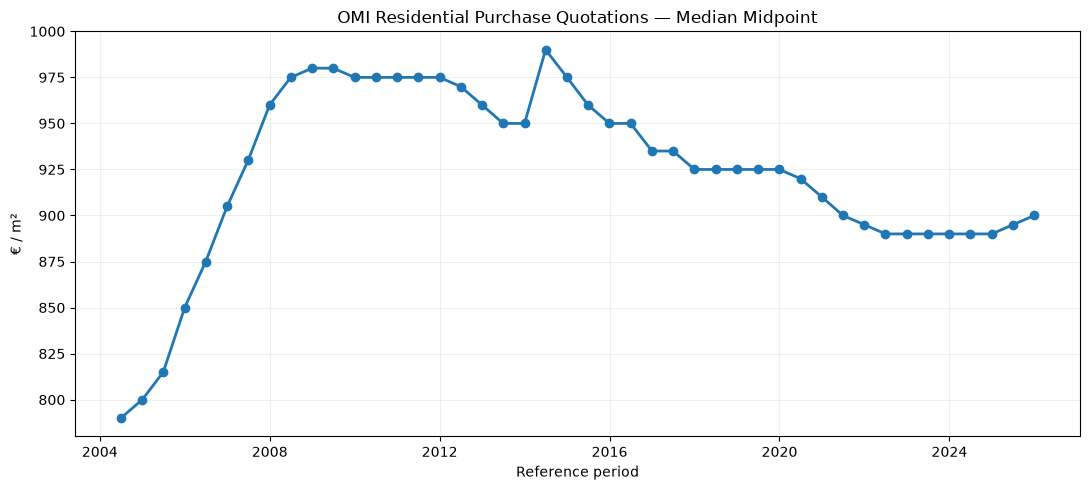

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(national_trend['reference_date'], national_trend['median_compr_mid'], marker='o', linewidth=2)
ax.set_title('OMI Residential Purchase Quotations — Median Midpoint')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## 12. Geographic price comparison

A portfolio analysis should not stop at a national average. Regional market levels are compared at the latest available period, with the aggregation logic shown explicitly.


In [17]:
latest_date = residential['reference_date'].max()
latest_regional = (
    residential.loc[residential['reference_date'].eq(latest_date)]
    .groupby('Regione', as_index=False)
    .agg(median_price_m2=('Compr_mid','median'), observations=('Compr_mid','count'), municipalities=('Comune_ISTAT','nunique'))
    .sort_values('median_price_m2', ascending=False)
)
display(latest_regional.head(15))


,Regione,median_price_m2,observations,municipalities
16,TRENTINO-ALTO ADIGE,"2,150.00",1645,282
7,LIGURIA,"1,500.00",1658,234
18,VALLE D'AOSTA/VALLE`E D'AOSTE,"1,275.00",480,74
15,TOSCANA,"1,250.00",1911,272
19,VENETO,"1,125.00",3178,561
8,LOMBARDIA,"1,125.00",7182,1500
4,EMILIA-ROMAGNA,"1,100.00",2767,330
6,LAZIO,"1,050.00",2161,378
9,MARCHE,905.00,2166,224
12,PUGLIA,765.00,1659,254


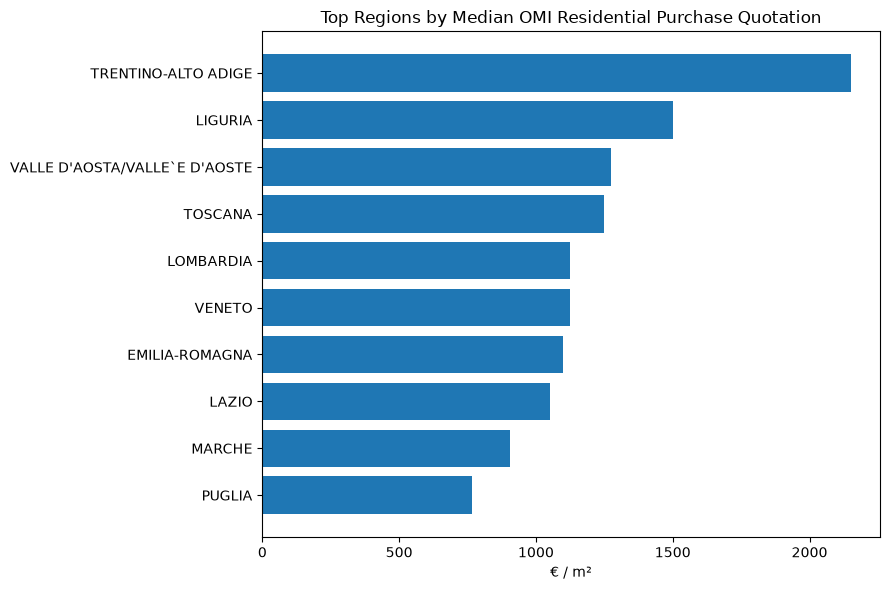

In [ ]:
top_regions = latest_regional.head(10).sort_values('median_price_m2')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_regions['Regione'], top_regions['median_price_m2'])
ax.set_title('Top Regions by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')
fig.tight_layout()
plt.show()

## 13. Quotation-range dispersion

The OMI quotation is an interval rather than a point estimate. Relative spread provides information about the width of the reported market range.


In [ ]:
spread_summary = (
    residential.groupby('reference_date', as_index=False)
    .agg(median_spread_pct=('Compr_spread_pct','median'), p75_spread_pct=('Compr_spread_pct', lambda s: s.quantile(0.75)))
)
display(spread_summary.tail(10))

,reference_date,median_spread_pct,p75_spread_pct
34,2021-06-30,32.26,38.30
35,2021-12-31,32.54,38.30
36,2022-06-30,32.56,38.30
37,2022-12-31,32.76,38.36
38,2023-06-30,32.84,38.46
39,2023-12-31,32.80,38.51
40,2024-06-30,32.80,38.53
41,2024-12-31,33.33,38.67
42,2025-06-30,33.33,38.60
43,2025-12-31,33.33,38.60


## 14. Final data-quality summary

The final checks provide a compact, auditable hand-off point for the next notebook.


In [20]:
final_quality = pd.DataFrame({
    'metric': ['rows','columns','periods','duplicate rows','purchase min > max','rental min > max','negative purchase quotations','negative rental quotations'],
    'value': [
        len(omi), omi.shape[1], omi['reference_period'].nunique(), int(omi.duplicated().sum()),
        int((omi['Compr_min'] > omi['Compr_max']).sum()), int((omi['Loc_min'] > omi['Loc_max']).sum()),
        int((omi[['Compr_min','Compr_max']] < 0).sum().sum()), int((omi[['Loc_min','Loc_max']] < 0).sum().sum())
    ],
})
display(final_quality)

,metric,value
0,rows,7516495
1,columns,31
2,periods,44
3,duplicate rows,0
4,purchase min > max,0
5,rental min > max,0
6,negative purchase quotations,0
7,negative rental quotations,0


## 15. Key takeaways and limitations

### What this notebook establishes

- Raw semiannual OMI files are consolidated into one reproducible analytical dataset.
- Data-quality assumptions are tested explicitly before analysis.
- Purchase and rental quotation ranges are preserved, while midpoint and spread metrics are clearly labelled as derived measures.
- Temporal and geographic coverage are quantified.
- Residential purchase quotations can be compared consistently across periods and regions.

### Important limitations

- OMI quotations are intervals, not transaction-level prices.
- The midpoint is a derived descriptive measure, not an official OMI average.
- Observations are heterogeneous across municipalities, zones, property types and conditions.
- Missing rental quotations must not automatically be interpreted as zero.
- Cross-dataset analysis with transaction volumes requires a carefully defined geographic and temporal key.

### Next notebook

**Notebook 02 — OMI Transactions** will analyse transaction volumes and prepare the variables required to combine market prices with market activity.
